In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df = pd.read_csv('SP500_2011_2025.csv')
df.sample(5)

,Date,Close,High,Low,Open,Volume
336,03-05-2012,1391.569946,1403.069946,1388.709961,1402.319946,4004910000
806,19-03-2014,1860.770020,1874.140015,1850.349976,1872.250000,3289210000
11,19-01-2011,1281.920044,1294.599976,1278.920044,1294.520020,4743710000
2655,22-07-2021,4367.479980,4369.870117,4350.060059,4361.270020,3358300000
384,12-07-2012,1334.760010,1341.290039,1325.410034,1341.290039,3654440000


In [3]:
df.columns = df.columns.str.strip().str.lower()
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

In [4]:
df.columns = df.columns.str.strip().str.lower()
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

In [5]:
print("\n--- Missing Value Count After Date/Type Conversion (by column) ---")
print(df.isnull().sum())


--- Missing Value Count After Date/Type Conversion (by column) ---
date      0
close     0
high      0
low       0
open      0
volume    0
dtype: int64


In [6]:
df_clean = df.dropna(subset=['close', 'open', 'high', 'low', 'volume']).copy()

In [7]:
print(df_clean.isnull().sum())

date      0
close     0
high      0
low       0
open      0
volume    0
dtype: int64


Calculate the daily log returns

In [8]:
df_clean['log_return'] = np.log(df_clean['close'] / df_clean['close'].shift(1))

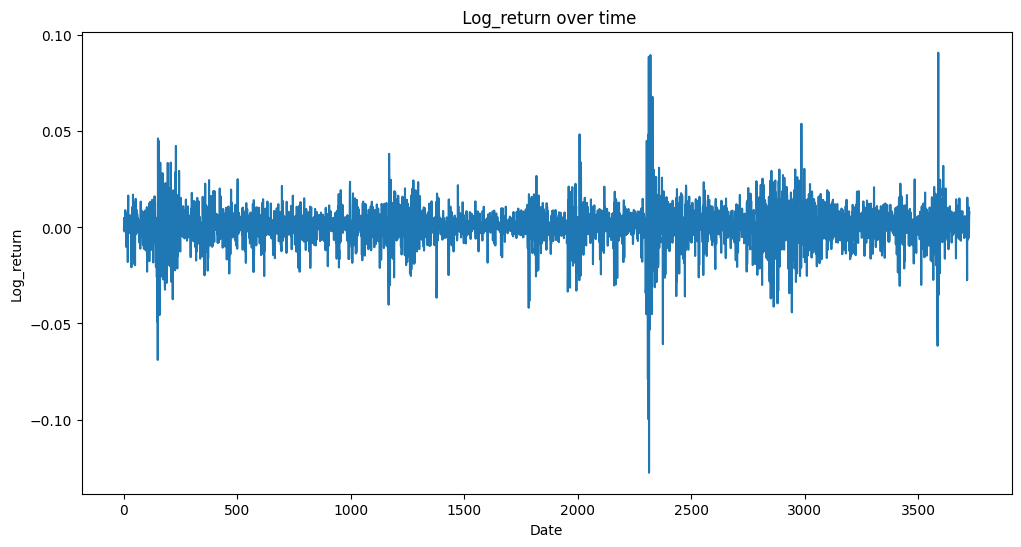

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(df_clean.index, df_clean['log_return'])
plt.title(' Log_return over time')
plt.xlabel('Date')
plt.ylabel('Log_return')
plt.grid(False)
plt.show()

In [10]:
df_index = df_clean.copy()

In [11]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=750ca26139e849090e8ba21bdb452c0e9506fa35d8a87b7943e41400c0ece215
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [12]:
import ta

In [13]:
VOLATILITY_WINDOW = 21  # ~1 month - Number of trading days (approx. 1 month) for realized volatility
df_index['realized_volatility'] = df_index['log_return'].rolling(VOLATILITY_WINDOW).std() * np.sqrt(252)

In [14]:
df_index['return_lag_1'] = df_index['log_return'].shift(1)

In [15]:
df_index['lagged_volatility'] = df_index['realized_volatility'].shift(1)

In [16]:
df_index['RSI'] = ta.momentum.rsi(df_index['close'], window=14)

In [17]:
macd_result = ta.trend.MACD(df_index['close'], window_fast=12, window_slow=26, window_sign=9)
df_index['MACD_Diff'] = macd_result.macd_diff() # Histogram

In [18]:
df_index['log_avg_volume'] = np.log(df_index['volume'])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [19]:
df_index.sample(5)

,date,close,high,low,open,volume,log_return,realized_volatility,return_lag_1,lagged_volatility,RSI,MACD_Diff,log_avg_volume
92,2011-05-16,1329.469971,1343.329956,1327.319946,1334.770020,3846250000,-0.006224,0.112776,-0.008100,0.110095,46.083040,-2.756874,22.070364
1974,2018-11-05,2738.310059,2744.270020,2717.939941,2726.370117,3650910000,0.005585,0.240177,-0.006337,0.238548,45.872506,5.036989,22.018242
1967,2018-10-25,2705.570068,2722.699951,2667.840088,2674.879883,4663930000,0.018454,0.215817,-0.031351,0.200684,34.643226,-13.097584,22.263124
2050,2019-02-27,2792.379883,2795.760010,2775.129883,2787.500000,3771790000,-0.000544,0.093406,-0.000791,0.099758,68.861899,0.820119,22.050816
753,2013-12-31,1848.359985,1849.439941,1842.410034,1842.609985,2312840000,0.003952,0.094899,-0.000179,0.094529,71.261747,3.917681,21.561742


In [20]:
df_index.head()

,date,close,high,low,open,volume,log_return,realized_volatility,return_lag_1,lagged_volatility,RSI,MACD_Diff,log_avg_volume
0,2011-01-03,1271.869995,1276.170044,1257.619995,1257.619995,4286670000,NaN,NaN,NaN,NaN,NaN,NaN,22.178776
1,2011-01-04,1270.199951,1274.119995,1262.660034,1272.949951,4796420000,-0.001314,NaN,NaN,NaN,NaN,NaN,22.291136
2,2011-01-05,1276.560059,1277.630005,1265.359985,1268.780029,4764920000,0.004995,NaN,-0.001314,NaN,NaN,NaN,22.284547
3,2011-01-06,1273.849976,1278.170044,1270.430054,1276.290039,4844100000,-0.002125,NaN,0.004995,NaN,NaN,NaN,22.301027
4,2011-01-07,1271.500000,1276.829956,1261.699951,1274.410034,4963110000,-0.001846,NaN,-0.002125,NaN,NaN,NaN,22.325298


In [21]:
df_index.shape

(3726, 13)

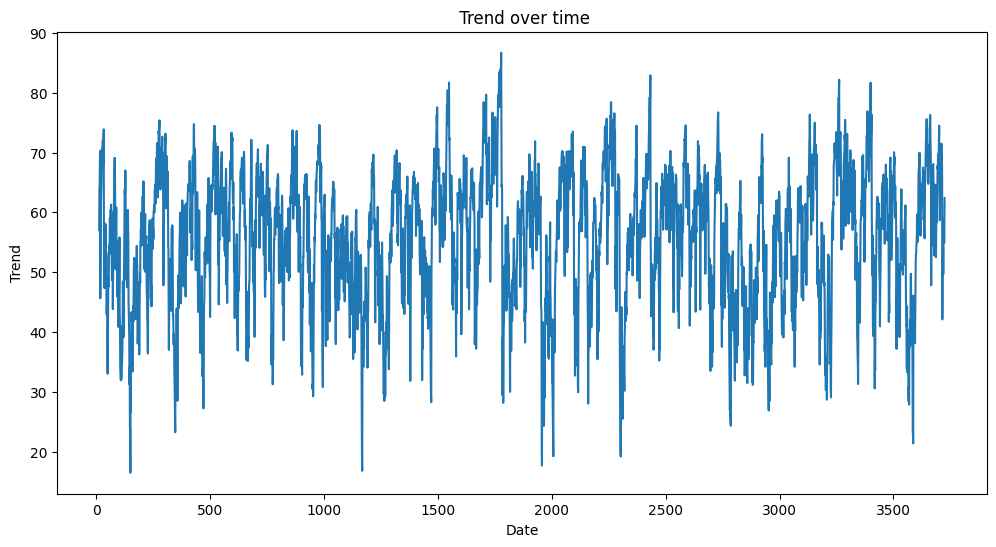

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(df_index.index, df_index['RSI'])
plt.title(' Trend over time')
plt.xlabel('Date')
plt.ylabel('Trend')
plt.grid(False)
plt.show()

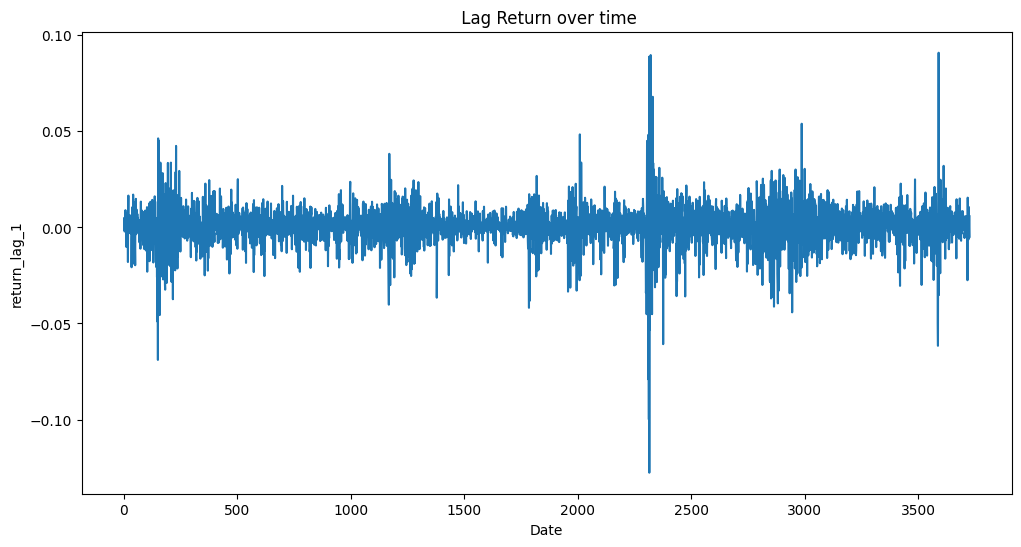

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(df_index.index, df_index['return_lag_1'])
plt.title(' Lag Return over time')
plt.xlabel('Date')
plt.ylabel('return_lag_1')
plt.grid(False)
plt.show()

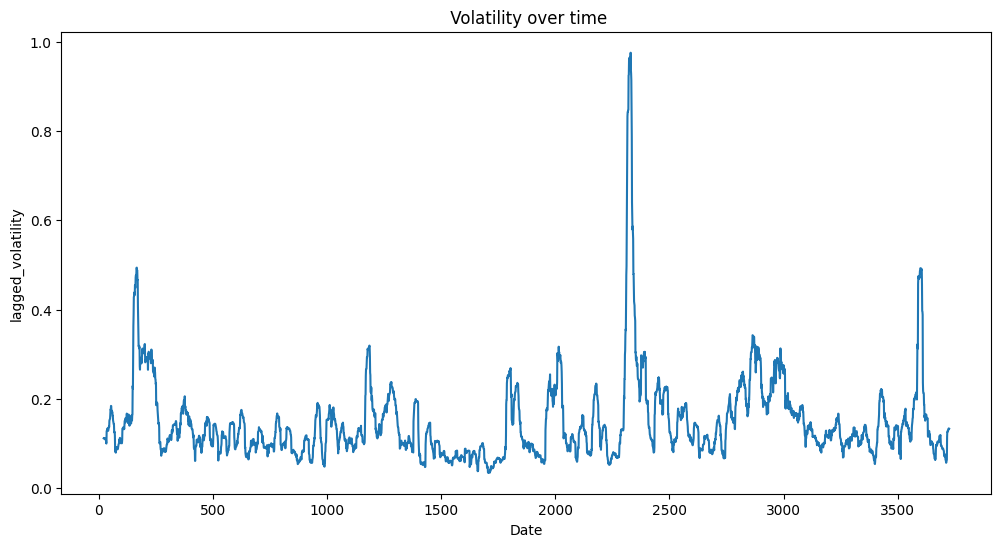

In [46]:
plt.figure(figsize=(12, 6))
plt.plot(df_index.index, df_index['lagged_volatility'])
plt.title(' Volatility over time')
plt.xlabel('Date')
plt.ylabel('lagged_volatility')
plt.grid(False)
plt.show()

| Objective Role | Feature    | Column              |
| -------------- | ---------- | ------------------- |
| Profit         | Return     | `return_lag_1`      |
| Risk           | Volatility | `lagged_volatility` |
| Trend          | RSI        | `RSI`               |
| Momentum       | MACD       | `MACD_Diff`         |
| Liquidity      | Volume     | `log_avg_volume`    |


In [47]:
# data = df_index[['return_lag_1','lagged_volatility','RSI','MACD_Diff','log_avg_volume']].dropna().iloc[::15][:200]
# R = data['return_lag_1'].values
# M = data['MACD_Diff'].values
# # sigma = data['lagged_volatility'].values
# # # Covariance matrix (strong improvement)
# # cov_matrix = np.diag(sigma**2)
# returns_matrix = data['return_lag_1'].values.reshape(-1,1)
# cov_matrix = np.cov(returns_matrix.T)

data = df_index[['return_lag_1','lagged_volatility','RSI','MACD_Diff','log_avg_volume']].dropna().iloc[::15][:200]

R = data['return_lag_1'].values
M = data['MACD_Diff'].values

sigma = data['lagged_volatility'].values
cov_matrix = np.diag(sigma ** 2)

n_vars = len(R)
assert cov_matrix.shape == (n_vars, n_vars)

In [48]:
print(cov_matrix)

[[0.01016332 0.         0.         ... 0.         0.         0.        ]
 [0.         0.0235029  0.         ... 0.         0.         0.        ]
 [0.         0.         0.02310153 ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.08485429 0.         0.        ]
 [0.         0.         0.         ... 0.         0.07139859 0.        ]
 [0.         0.         0.         ... 0.         0.         0.04086248]]


In [52]:
cov_matrix.shape

(200, 200)

In [49]:
data

,return_lag_1,lagged_volatility,RSI,MACD_Diff,log_avg_volume
33,0.003071,0.100813,73.874138,1.793218,20.873675
48,0.007056,0.153307,44.020138,-3.810392,22.122074
63,0.004951,0.151992,60.300213,4.632665,22.163987
78,-0.001594,0.086570,63.562181,1.868152,22.086307
93,-0.006224,0.112776,45.864512,-3.319905,22.122962
...,...,...,...,...,...
2958,0.025555,0.260879,46.597030,-3.030219,22.361598
2973,0.011812,0.287717,57.765246,33.586989,22.300825
2988,-0.008976,0.291298,61.022417,24.033756,22.335761
3003,-0.014504,0.267205,49.357602,-11.521459,22.138646


In [ ]:
print(cov_matrix)

[[ 1.74612552e-05  1.31969621e-05 -3.99692601e-06  4.77704942e-06
  -1.00838330e-05  4.23812109e-07 -5.71007197e-06 -8.32001724e-07
   2.20848620e-07 -1.26578300e-05]
 [ 1.31969621e-05  9.05656513e-05 -1.00578523e-05 -3.84099682e-05
  -5.12278330e-05  9.05399294e-06  1.36552490e-07 -7.24911512e-06
  -2.07028444e-05  2.25313828e-05]
 [-3.99692601e-06 -1.00578523e-05  1.20070046e-05 -1.53111312e-05
   9.53931729e-06 -1.36015518e-05  9.46610896e-07  5.76309840e-06
  -1.03288002e-05  1.10432658e-05]
 [ 4.77704942e-06 -3.84099682e-05 -1.53111312e-05  9.93352780e-05
   4.25950056e-06  1.89479694e-05  5.25545241e-06 -2.48834350e-05
   5.12836467e-05 -5.08743991e-05]
 [-1.00838330e-05 -5.12278330e-05  9.53931729e-06  4.25950056e-06
   1.44402334e-04 -1.01426392e-05 -1.74383546e-06 -7.73506885e-06
  -6.99490939e-06 -1.43670010e-05]
 [ 4.23812109e-07  9.05399294e-06 -1.36015518e-05  1.89479694e-05
  -1.01426392e-05  3.67498975e-05 -6.47267780e-07 -2.57342400e-05
   4.91857938e-08 -1.43061410e-05

Scalarization Technique

In [50]:
from scipy.optimize import minimize
w1,w2,w3=0.6,0.3,0.1

def objective(x):
    return -( w1*np.dot(R,x)
             - w2*np.dot(x.T, np.dot(cov_matrix, x))
             + w3*np.dot(np.tanh(M), x) )

constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
bounds = [(0,1)]*len(R)

x0 = np.ones(len(R))/len(R)

res = minimize(objective, x0, bounds=bounds, constraints=constraints)

x_scalar = res.x

In [51]:
print(x_scalar)

[0.00000000e+00 3.18746274e-16 8.11081708e-16 0.00000000e+00
 0.00000000e+00 5.99056994e-16 1.74014601e-01 0.00000000e+00
 8.35294169e-16 0.00000000e+00 3.24679339e-16 0.00000000e+00
 5.96676097e-16 9.02481501e-16 3.70675569e-16 2.71650044e-02
 8.65362059e-16 6.80407232e-16 0.00000000e+00 5.39492784e-16
 0.00000000e+00 7.61180250e-16 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 5.78208197e-16 6.77279326e-16
 5.00055983e-16 8.28871580e-16 0.00000000e+00 3.58983963e-16
 0.00000000e+00 9.01574752e-16 4.41178197e-16 7.67492331e-16
 1.21296264e-16 0.00000000e+00 4.27871767e-16 5.36264135e-16
 0.00000000e+00 5.39002396e-16 8.60879420e-16 0.00000000e+00
 3.99402605e-16 0.00000000e+00 3.69006430e-16 4.36942316e-16
 0.00000000e+00 1.18378757e-15 0.00000000e+00 0.00000000e+00
 9.06939676e-16 0.00000000e+00 5.16735169e-16 0.00000000e+00
 5.98988294e-16 4.14568781e-16 1.12950598e-15 0.00000000e+00
 6.67032635e-16 5.16313310e-16 2.97949740e-17 0.00000000e+00
 3.33807960e-16 1.914956

In [77]:
import numpy as np
from scipy.optimize import minimize

# Assuming R, cov_matrix, and M are already defined from your dataset
w1, w2, w3 = 0.6, 0.3, 0.1
n_vars = len(R)

constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0}
bounds = [(0, 1)] * n_vars
x0 = np.ones(n_vars) / n_vars

# ==========================================
# PHASE 1: Define Individual Objectives
# (All framed as minimization so the solver understands them)
# ==========================================
def obj_return(x):
    return -np.dot(R, x)  # Minimizing negative return = Maximizing return

def obj_risk(x):
    return np.dot(x.T, np.dot(cov_matrix, x))  # Minimizing variance (risk)

def obj_momentum(x):
    return -np.dot(np.tanh(M), x)  # Minimizing negative momentum = Maximizing momentum

# ==========================================
# PHASE 2: Find Ideal (Best) and Nadir (Worst) Limits
# ==========================================
ideals = {}
nadirs = {}

# Find limits for Return
ideals['ret'] = minimize(obj_return, x0, bounds=bounds, constraints=constraints).fun
nadirs['ret'] = -minimize(lambda x: -obj_return(x), x0, bounds=bounds, constraints=constraints).fun

# Find limits for Risk
ideals['risk'] = minimize(obj_risk, x0, bounds=bounds, constraints=constraints).fun
nadirs['risk'] = -minimize(lambda x: -obj_risk(x), x0, bounds=bounds, constraints=constraints).fun

# Find limits for Momentum
ideals['mom'] = minimize(obj_momentum, x0, bounds=bounds, constraints=constraints).fun
nadirs['mom'] = -minimize(lambda x: -obj_momentum(x), x0, bounds=bounds, constraints=constraints).fun

# ==========================================
# PHASE 3: The Normalized Weighted Sum Objective
# ==========================================
def normalized_objective(x):
    # Get the raw values for the current portfolio 'x'
    raw_ret = obj_return(x)
    raw_risk = obj_risk(x)
    raw_mom = obj_momentum(x)

    # Normalize each objective: (Raw - Ideal) / (Nadir - Ideal)
    # Note: We add 1e-9 to prevent dividing by zero if Ideal and Nadir are identical
    norm_ret = (raw_ret - ideals['ret']) / (nadirs['ret'] - ideals['ret'] + 1e-9)
    norm_risk = (raw_risk - ideals['risk']) / (nadirs['risk'] - ideals['risk'] + 1e-9)
    norm_mom = (raw_mom - ideals['mom']) / (nadirs['mom'] - ideals['mom'] + 1e-9)

    # Apply your weights to the newly normalized 0-to-1 values
    return (w1 * norm_ret) + (w2 * norm_risk) + (w3 * norm_mom)

# ==========================================
# PHASE 4: Final Solve
# ==========================================
res = minimize(normalized_objective, x0, bounds=bounds, constraints=constraints)

x_scalar = res.x

print("Optimized Normalized Portfolio Weights:")
print(np.round(x_scalar, 4))

Optimized Normalized Portfolio Weights:
[0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     

Running optimizer for all weight combinations...


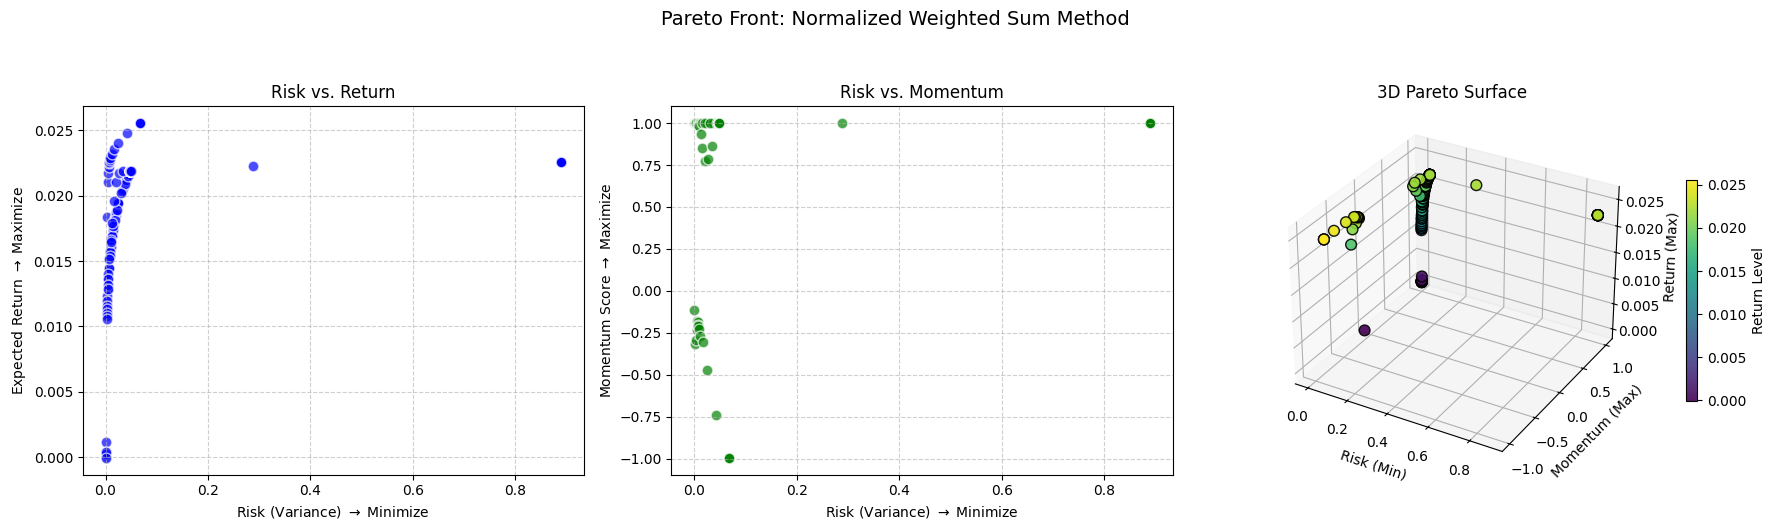

In [54]:
pareto_returns = []
pareto_risks = []
pareto_momentums = []

steps = 15  # The number of weight combinations. Increase for a denser plot.
print(f"Running optimizer for all weight combinations...")

for i in range(steps + 1):
    for j in range(steps + 1 - i):
        # Generate sweeping weights that always sum to 1.0
        w1 = i / steps
        w2 = j / steps
        w3 = 1.0 - w1 - w2

        # Define normalized objective dynamically with the current loop weights
        def normalized_objective(x, weight1=w1, weight2=w2, weight3=w3):
            raw_ret = obj_return(x)
            raw_risk = obj_risk(x)
            raw_mom = obj_momentum(x)

            norm_ret = (raw_ret - ideals['ret']) / (nadirs['ret'] - ideals['ret'] + 1e-9)
            norm_risk = (raw_risk - ideals['risk']) / (nadirs['risk'] - ideals['risk'] + 1e-9)
            norm_mom = (raw_mom - ideals['mom']) / (nadirs['mom'] - ideals['mom'] + 1e-9)

            return (weight1 * norm_ret) + (weight2 * norm_risk) + (weight3 * norm_mom)

        # Solve for this specific weight combination
        res = minimize(normalized_objective, x0, bounds=bounds, constraints=constraints)

        # Store the unnormalized (raw) real-world values for plotting
        pareto_returns.append(-obj_return(res.x))  # Flip return sign back to positive
        pareto_risks.append(obj_risk(res.x))
        pareto_momentums.append(-obj_momentum(res.x)) # Flip momentum sign back to positive

# ==========================================
# PHASE 5: VISUALIZATION
# ==========================================
fig = plt.figure(figsize=(18, 5))
fig.suptitle('Pareto Front: Normalized Weighted Sum Method', fontsize=14, y=1.05)

# Plot 1: Risk vs. Return
ax1 = fig.add_subplot(131)
ax1.scatter(pareto_risks, pareto_returns, c='blue', alpha=0.7, edgecolors='w', s=60)
ax1.set_title('Risk vs. Return', fontsize=12)
ax1.set_xlabel('Risk (Variance) $\\rightarrow$ Minimize')
ax1.set_ylabel('Expected Return $\\rightarrow$ Maximize')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Risk vs. Momentum
ax2 = fig.add_subplot(132)
ax2.scatter(pareto_risks, pareto_momentums, c='green', alpha=0.7, edgecolors='w', s=60)
ax2.set_title('Risk vs. Momentum', fontsize=12)
ax2.set_xlabel('Risk (Variance) $\\rightarrow$ Minimize')
ax2.set_ylabel('Momentum Score $\\rightarrow$ Maximize')
ax2.grid(True, linestyle='--', alpha=0.6)

# Plot 3: 3D Visualization
ax3 = fig.add_subplot(133, projection='3d')
scatter3d = ax3.scatter(pareto_risks, pareto_momentums, pareto_returns,
                        c=pareto_returns, cmap='viridis', s=60, alpha=0.9, edgecolors='k')
ax3.set_title('3D Pareto Surface', fontsize=12)
ax3.set_xlabel('Risk (Min)')
ax3.set_ylabel('Momentum (Max)')
ax3.set_zlabel('Return (Max)')

cbar = fig.colorbar(scatter3d, ax=ax3, shrink=0.6, pad=0.1)
cbar.set_label('Return Level')

plt.tight_layout()
plt.show()

Heuristic Technique (NSGA ii)

In [67]:
def dominates(p_obj,q_obj):
  return all(p<=q for p,q in zip(p_obj,q_obj)) and any(p<q for p,q in zip(p_obj,q_obj))

# FAST NON-DOMINATED SORTING (Stage 1 & 2)

In [55]:
def fast_non_dominated_sorting(objectives):
    """
    Implements Algorithm 3: Fast Non-Dominated Sorting.
    Returns the fronts and the rank of each solution.
    """
    N = len(objectives)
    S = [[] for _ in range(N)] # S_p: set of solutions dominated by p
    n = [0] * N                # n_p: domination counter for p
    rank = [0] * N
    F = [[]]                   # F[0] corresponds to F_1 (the first front)

    # STAGE-1: Calculate domination counts and first front
    for p in range(N):
        for q in range(N):
            if p == q:
                continue
            if dominates(objectives[p], objectives[q]):
                S[p].append(q) # Add q to the set of solutions dominated by p
            elif dominates(objectives[q], objectives[p]):
                n[p] += 1      # Increase the domination counter of p

        if n[p] == 0:
            rank[p] = 1        # p belongs to the first front
            F[0].append(p)

    # STAGE-2: Iteratively construct subsequent fronts
    i = 0
    while len(F[i]) > 0:
        Q = []                 # Used to store members of the next front
        for p in F[i]:
            for q in S[p]:
                n[q] -= 1
                if n[q] == 0:
                    rank[q] = i + 2  # q_rank = i + 1 (adjusted for 0-indexing)
                    Q.append(q)      # q belongs to the next front
        i += 1
        if len(Q) > 0:
            F.append(Q)
        else:
            break

    return F, rank

# CROWDING DISTANCE

In [56]:
def assign_crowding_distance(F_front, objectives):
    """
    Calculates the crowding distance to preserve diversity in a specific front.
    """
    r = len(F_front)
    distances = {index: 0 for index in F_front}

    if r == 0:
        return distances
    if r <= 2:
        # Boundary points get an infinite distance
        for index in F_front:
            distances[index] = float('inf')
        return distances

    num_objectives = len(objectives[0])

    for m in range(num_objectives):
        # Sort the front based on objective m
        sorted_front = sorted(F_front, key=lambda x: objectives[x][m])

        # Boundary solutions are assigned infinite distance
        distances[sorted_front[0]] = float('inf')
        distances[sorted_front[-1]] = float('inf')

        f_min = objectives[sorted_front[0]][m]
        f_max = objectives[sorted_front[-1]][m]

        if f_max - f_min == 0:
            continue

        # Calculate distance for intermediate solutions
        for i in range(1, r - 1):
            distances[sorted_front[i]] += (objectives[sorted_front[i+1]][m] - objectives[sorted_front[i-1]][m]) / (f_max - f_min)

    return distances

# SELECTION AND SURVIVOR

In [57]:
def crowded_binary_tournament(p, q, rank, distance):
    """
    Returns the winner of a tournament based on rank and crowding distance.
    """
    if rank[p] < rank[q]:
        return p
    elif rank[p] == rank[q] and distance[p] > distance[q]:
        return p
    else:
        return q

In [58]:
def survivor_selection(P_merged, F, distances, population_size):
    """
    P(t+1) := Survivor(P_hat(t)) logic.
    Extracts exactly N individuals for the next generation.
    """
    P_next = []

    for front in F:
        if len(P_next) + len(front) <= population_size:
            # Entire front fits
            P_next.extend(front)
        else:
            # Sort the final front by crowding distance descending and slice the remainder needed
            remaining_slots = population_size - len(P_next)
            sorted_front = sorted(front, key=lambda x: distances[x], reverse=True)
            P_next.extend(sorted_front[:remaining_slots])
            break

    return P_next

NSGA-ii

In [59]:
import random

def nsga_ii(evaluate_function, generate_population, variation_function, pop_size=100, max_gen=50):
    """
    Algorithm 2 NSGA-II main control loop.
    """
    # 1: Solution representation, t:=0, Maximum allowed generation = T
    t = 0

    # 2: Initialize random population (P(t))
    P = generate_population(pop_size)

    while t < max_gen:  # 4: while t < T do
        # 3. Evaluate P(t)
        objectives_P = [evaluate_function(ind) for ind in P]

        # Assign rank and crowding distance
        F, rank = fast_non_dominated_sorting(objectives_P)
        distances = {}
        for front in F:
            distances.update(assign_crowding_distance(front, objectives_P))

        # 5: M(t) := Selection(P(t)) (Crowded Binary Tournament Selection)
        M = []
        for _ in range(pop_size):
            p1, p2 = random.sample(range(pop_size), 2)
            winner = crowded_binary_tournament(p1, p2, rank, distances)
            M.append(P[winner])

        # 6: Q(t) := Variation(M(t)) (Crossover and Mutation)
        Q = variation_function(M)

        # Merge population P(t) = P(t) U Q(t)
        P_merged = P + Q

        # Evaluate merged population
        objectives_merged = [evaluate_function(ind) for ind in P_merged]

        # Assign rank and diversity to P_merged
        F_merged, rank_merged = fast_non_dominated_sorting(objectives_merged)
        distances_merged = {}
        for front in F_merged:
            distances_merged.update(assign_crowding_distance(front, objectives_merged))

        # 10: P(t+1) := Survivor(P_merged)
        # Get the indices of the surviving population
        surviving_indices = survivor_selection(P_merged, F_merged, distances_merged, pop_size)

        # Reconstruct P(t+1)
        P = [P_merged[i] for i in surviving_indices]

        # 11: t := t + 1
        t += 1

    return P

In [60]:
def sbx_crossover(p1, p2, eta_c=20, lower_bound=0.0, upper_bound=1.0):
    """
    Simulated Binary Crossover (SBX) for real-coded GAs.
    eta_c: Distribution index for crossover. (Default 20 is standard)
    """
    p1 = np.array(p1)
    p2 = np.array(p2)
    c1, c2 = np.copy(p1), np.copy(p2)

    # Iterate through each gene (variable)
    for i in range(len(p1)):
        # 50% chance to swap/crossover each specific gene
        if random.random() <= 0.5:
            if abs(p1[i] - p2[i]) > 1e-14: # Only crossover if they are different
                u = random.random()

                # Calculate the spread factor Beta (beta_q)
                if u <= 0.5:
                    beta_q = (2.0 * u) ** (1.0 / (eta_c + 1.0))
                else:
                    beta_q = (1.0 / (2.0 * (1.0 - u))) ** (1.0 / (eta_c + 1.0))

                # Create children
                c1[i] = 0.5 * ((1 + beta_q) * p1[i] + (1 - beta_q) * p2[i])
                c2[i] = 0.5 * ((1 - beta_q) * p1[i] + (1 + beta_q) * p2[i])

                # Enforce boundaries [0, 1]
                c1[i] = min(max(c1[i], lower_bound), upper_bound)
                c2[i] = min(max(c2[i], lower_bound), upper_bound)

    return c1, c2

In [61]:
def polynomial_mutation(child, eta_m=20, lower_bound=0.0, upper_bound=1.0, mutation_rate=None):
    """
    Polynomial Mutation for real-coded GAs.
    eta_m: Distribution index for mutation. (Default 20 is standard)
    """
    n_vars = len(child)
    if mutation_rate is None:
        mutation_rate = 1.0 / n_vars # Standard practice: 1/N chance per gene

    for i in range(n_vars):
        if random.random() <= mutation_rate:
            u = random.random()

            # Calculate the perturbation delta (delta_q)
            if u < 0.5:
                delta_q = (2.0 * u) ** (1.0 / (eta_m + 1.0)) - 1.0
            else:
                delta_q = 1.0 - (2.0 * (1.0 - u)) ** (1.0 / (eta_m + 1.0))

            # Apply mutation
            child[i] = child[i] + delta_q * (upper_bound - lower_bound)

            # Enforce boundaries [0, 1]
            child[i] = min(max(child[i], lower_bound), upper_bound)

    return child

In [62]:
def variation(population):
    offspring = []
    pop_size = len(population)

    # We step by 2 because SBX produces 2 children at a time
    for i in range(0, pop_size, 2):
        # 1. Selection (Tournament winners)
        p1, p2 = random.sample(population, 2)

        # 2. SBX Crossover
        # Cross probability is usually high (e.g., 90%)
        if random.random() < 0.90:
            c1, c2 = sbx_crossover(p1, p2, eta_c=20)
        else:
            # If no crossover, children are exact copies of parents
            c1, c2 = np.copy(p1), np.copy(p2)

        # 3. Polynomial Mutation
        c1 = polynomial_mutation(c1, eta_m=20)
        c2 = polynomial_mutation(c2, eta_m=20)

        # 4. Repair Constraint (Force sum to 1.0 for the portfolio)
        children = [c1, c2]
        for child in children:
            if np.sum(child) > 0:
                child = child / np.sum(child)
            else:
                child = np.ones(n_vars) / n_vars # Failsafe

            offspring.append(list(child))

    # Ensure exactly pop_size offspring are returned (in case pop_size was odd)
    return offspring[:pop_size]

In [63]:
def evaluate_portfolio(x):
    x = np.array(x)

    # 1. Maximize Return (Minimize negative)
    f1 = -np.dot(R, x)

    # 2. Minimize Risk (Variance)
    f2 = np.dot(x.T, np.dot(cov_matrix, x))

    # 3. Maximize Momentum (Minimize negative)
    # Using np.tanh(M) keeps large MACD values from mathematically dominating
    f3 = -np.dot(np.tanh(M), x)

    return [f1, f2, f3]

In [64]:
def generate_valid_population(size):
    pop = []
    for _ in range(size):
        x = np.random.rand(n_vars)
        x = x / np.sum(x)  # Force weights to sum to 1.0
        pop.append(list(x))
    return pop

In [71]:
def nsga_ii(pop_size=200, max_gen=100):
    P = generate_valid_population(pop_size)

    for t in range(max_gen):
        objectives_P = [evaluate_portfolio(ind) for ind in P]

        # Parent evaluation
        F, rank = fast_non_dominated_sorting(objectives_P)
        distances = {}
        for front in F: distances.update(assign_crowding_distance(front, objectives_P))

        # Variation
        Q = variation(P)
        P_merged = P + Q
        objectives_merged = [evaluate_portfolio(ind) for ind in P_merged]

        # Merged evaluation
        F_merged, rank_merged = fast_non_dominated_sorting(objectives_merged)
        distances_merged = {}
        for front in F_merged: distances_merged.update(assign_crowding_distance(front, objectives_merged))

        # Survivor Selection
        P_next = []
        for front in F_merged:
            if len(P_next) + len(front) <= pop_size:
                P_next.extend(front)
            else:
                remaining = pop_size - len(P_next)
                sorted_front = sorted(front, key=lambda x: distances_merged[x], reverse=True)
                P_next.extend(sorted_front[:remaining])
                break
        P = [P_merged[i] for i in P_next]

    return P

In [84]:
pareto_portfolios = nsga_ii(pop_size=200, max_gen=100)

print(f"Algorithm generated {len(pareto_portfolios)} optimized portfolios.")

# View the optimal trade-off solutions
for i in range(3): # Let's look at 3 options
    best_portfolio = np.array(pareto_portfolios[i])
    scores = evaluate_portfolio(best_portfolio)

    print(f"\n--- Pareto Portfolio Option {i+1} ---")
    print(f"Expected Return:  {-scores[0]:.4f} (Higher is better)")
    print(f"Risk (Variance):  {scores[1]:.4f} (Lower is better)")
    print(f"Momentum Score:   {-scores[2]:.4f} (Higher is better)")
    print("Asset Weights:")
    print(np.round(best_portfolio, 3))

Algorithm generated 200 optimized portfolios.

--- Pareto Portfolio Option 1 ---
Expected Return:  0.0008 (Higher is better)
Risk (Variance):  0.0001 (Lower is better)
Momentum Score:   0.0290 (Higher is better)
Asset Weights:
[0.002 0.008 0.004 0.002 0.004 0.008 0.005 0.005 0.001 0.002 0.003 0.006
 0.005 0.003 0.003 0.002 0.01  0.004 0.003 0.003 0.006 0.001 0.    0.005
 0.003 0.005 0.004 0.004 0.001 0.006 0.006 0.009 0.007 0.002 0.008 0.005
 0.003 0.007 0.008 0.009 0.003 0.007 0.003 0.002 0.005 0.006 0.007 0.002
 0.009 0.003 0.006 0.005 0.001 0.001 0.003 0.017 0.007 0.004 0.    0.005
 0.006 0.01  0.009 0.001 0.005 0.005 0.001 0.001 0.005 0.006 0.005 0.007
 0.005 0.008 0.005 0.001 0.    0.    0.005 0.    0.006 0.008 0.003 0.003
 0.004 0.004 0.004 0.005 0.008 0.001 0.006 0.001 0.006 0.026 0.006 0.005
 0.014 0.002 0.005 0.006 0.004 0.046 0.001 0.003 0.004 0.005 0.005 0.008
 0.014 0.002 0.004 0.006 0.062 0.005 0.005 0.008 0.001 0.    0.003 0.005
 0.003 0.008 0.005 0.006 0.008 0.006 0.008 

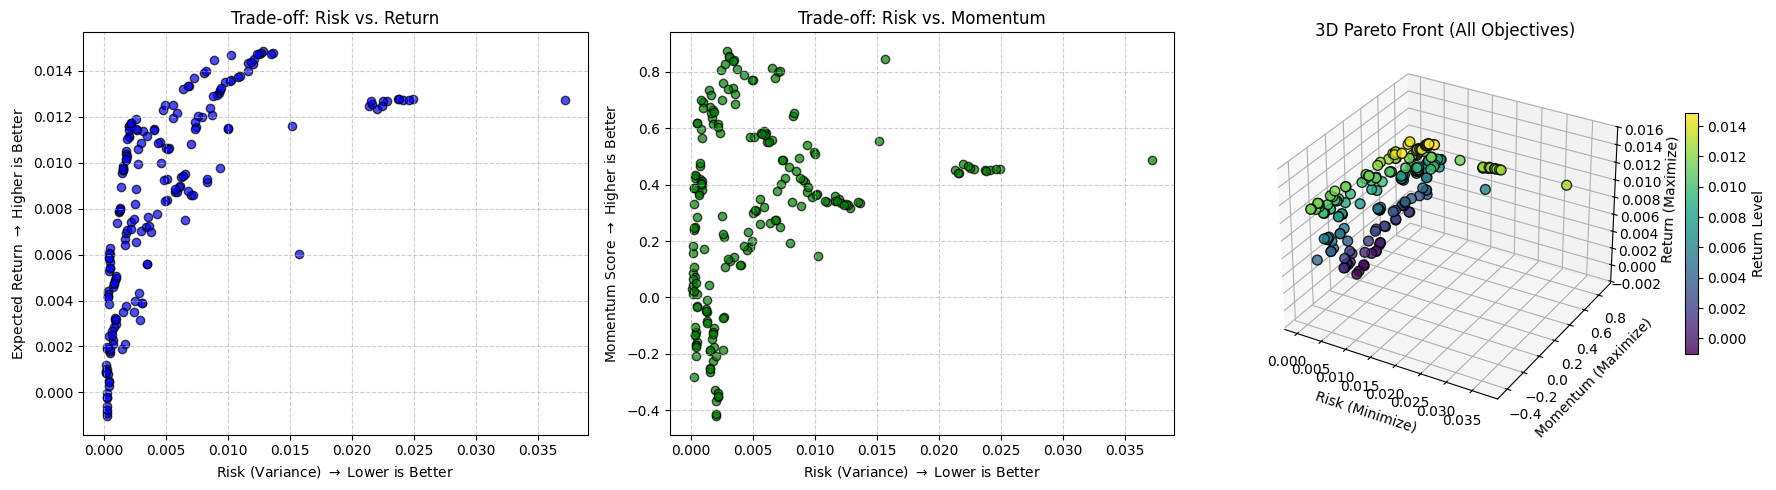

In [85]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 1. Extract the objective scores from the optimized portfolios
returns = []
risks = []
momentums = []

# (Assuming 'pareto_portfolios' and 'evaluate_portfolio' are in memory from the previous step)
for x in pareto_portfolios:
    scores = evaluate_portfolio(x)
    # Flip the signs back for Return and Momentum so higher is better on the graph
    returns.append(-scores[0])
    risks.append(scores[1])    # Risk is already positive (we minimize it)
    momentums.append(-scores[2])

# 2. Set up the plotting environment
fig = plt.figure(figsize=(18, 5))

# ==========================================
# PLOT 1: Risk vs. Return (Traditional Markowitz Efficient Frontier)
# ==========================================
ax1 = fig.add_subplot(131)
ax1.scatter(risks, returns, c='blue', alpha=0.7, edgecolors='k')
ax1.set_title('Trade-off: Risk vs. Return', fontsize=12)
ax1.set_xlabel('Risk (Variance) $\\rightarrow$ Lower is Better')
ax1.set_ylabel('Expected Return $\\rightarrow$ Higher is Better')
ax1.grid(True, linestyle='--', alpha=0.6)

# ==========================================
# PLOT 2: Risk vs. Momentum
# ==========================================
ax2 = fig.add_subplot(132)
ax2.scatter(risks, momentums, c='green', alpha=0.7, edgecolors='k')
ax2.set_title('Trade-off: Risk vs. Momentum', fontsize=12)
ax2.set_xlabel('Risk (Variance) $\\rightarrow$ Lower is Better')
ax2.set_ylabel('Momentum Score $\\rightarrow$ Higher is Better')
ax2.grid(True, linestyle='--', alpha=0.6)

# ==========================================
# PLOT 3: 3D Visualization of All Three Objectives
# ==========================================
ax3 = fig.add_subplot(133, projection='3d')
# Color the 3D dots based on their Return value using a colormap
scatter3d = ax3.scatter(risks, momentums, returns, c=returns, cmap='viridis', s=50, alpha=0.8, edgecolors='k')

ax3.set_title('3D Pareto Front (All Objectives)', fontsize=12)
ax3.set_xlabel('Risk (Minimize)')
ax3.set_ylabel('Momentum (Maximize)')
ax3.set_zlabel('Return (Maximize)')

# Add a color bar to indicate Return levels
cbar = fig.colorbar(scatter3d, ax=ax3, shrink=0.6, pad=0.1)
cbar.set_label('Return Level')

plt.tight_layout()
plt.show()

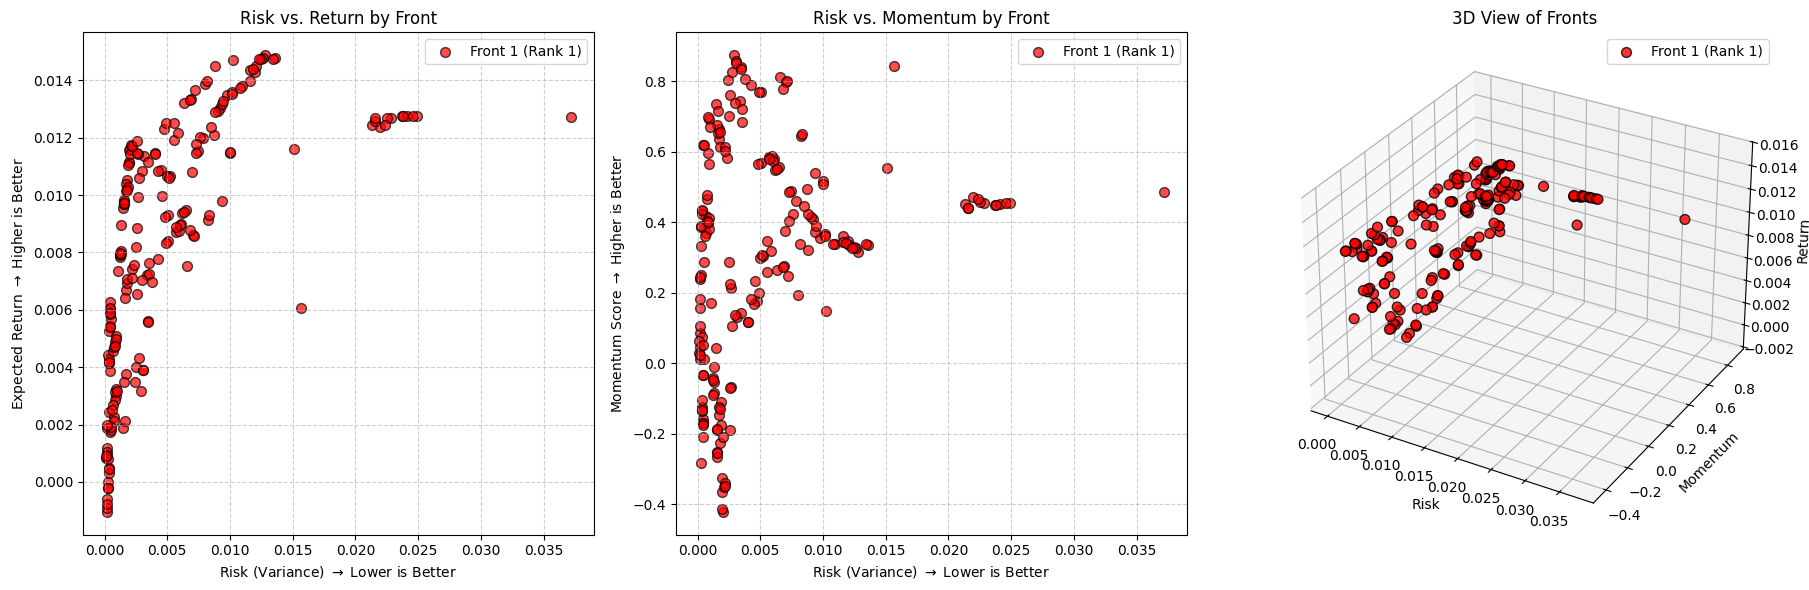

In [86]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 1. Evaluate all final portfolios to get their objective scores
final_objectives = [evaluate_portfolio(p) for p in pareto_portfolios]

# 2. Sort the final population into Pareto Fronts
# (Using the function we defined earlier in the NSGA-II core)
F, ranks = fast_non_dominated_sorting(final_objectives)

# 3. Set up the plotting environment
fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(131)
ax1.set_title('Risk vs. Return by Front', fontsize=12)
ax1.set_xlabel('Risk (Variance) $\\rightarrow$ Lower is Better')
ax1.set_ylabel('Expected Return $\\rightarrow$ Higher is Better')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = fig.add_subplot(132)
ax2.set_title('Risk vs. Momentum by Front', fontsize=12)
ax2.set_xlabel('Risk (Variance) $\\rightarrow$ Lower is Better')
ax2.set_ylabel('Momentum Score $\\rightarrow$ Higher is Better')
ax2.grid(True, linestyle='--', alpha=0.6)

ax3 = fig.add_subplot(133, projection='3d')
ax3.set_title('3D View of Fronts', fontsize=12)
ax3.set_xlabel('Risk')
ax3.set_ylabel('Momentum')
ax3.set_zlabel('Return')

# 4. Define a color palette for the different fronts
# Front 1 will be Red, Front 2 Blue, Front 3 Green, etc.
colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'gray']

# 5. Plot each front one by one
for i, front_indices in enumerate(F):
    # If there are more fronts than colors, default to black
    color = colors[i] if i < len(colors) else 'black'
    front_label = f'Front {i+1} (Rank {i+1})'

    # Extract the individual scores for this specific front
    # Remember to flip Return and Momentum signs back for the graph
    front_returns = [-final_objectives[idx][0] for idx in front_indices]
    front_risks = [final_objectives[idx][1] for idx in front_indices]
    front_momentums = [-final_objectives[idx][2] for idx in front_indices]

    # Plot on Risk vs Return (2D)
    ax1.scatter(front_risks, front_returns, c=color, s=50, alpha=0.7, edgecolors='k', label=front_label)

    # Plot on Risk vs Momentum (2D)
    ax2.scatter(front_risks, front_momentums, c=color, s=50, alpha=0.7, edgecolors='k', label=front_label)

    # Plot on 3D Axis
    ax3.scatter(front_risks, front_momentums, front_returns, c=color, s=50, alpha=0.8, edgecolors='k', label=front_label)

# 6. Add the legends
ax1.legend(loc='best')
ax2.legend(loc='best')
ax3.legend(loc='best')

plt.tight_layout()
plt.show()

Dataset successfully loaded. Optimizing a 200-asset portfolio.
Finding Ideal and Nadir limits for normalization...
Running Weighted Sum sweeps for 200 variables (This may take a minute)...
Running NSGA-II solver...

=== MULTI-OBJECTIVE COMPARISON METRICS ===
NSGA-II Spread:      0.150238 (Lower is better)
Weighted Sum Spread: 0.578856
NSGA-II Volume:      0.125450 (Higher is better)
Weighted Sum Volume: 0.142538


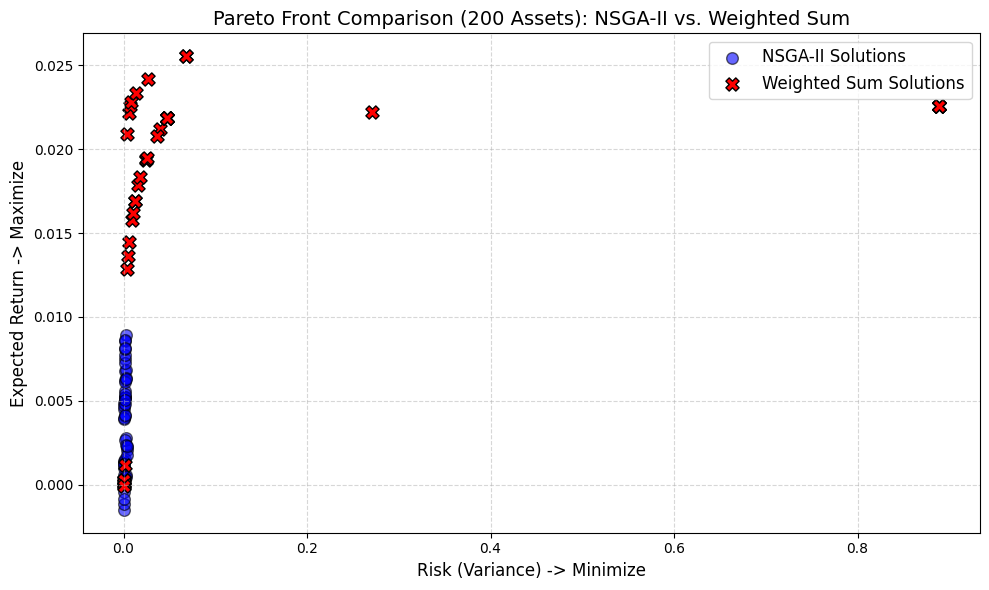

In [80]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ==========================================
# 1. DATASET SETUP (Using your exact logic)
# ==========================================
# (Assuming df_index is already loaded in your notebook)
try:
    data = df_index[['return_lag_1','lagged_volatility','RSI','MACD_Diff','log_avg_volume']].dropna().iloc[::15][:200]
    R = data['return_lag_1'].values
    M = data['MACD_Diff'].values

    sigma = data['lagged_volatility'].values
    cov_matrix = np.diag(sigma ** 2)

    n_vars = len(R)
    assert cov_matrix.shape == (n_vars, n_vars)
    print(f"Dataset successfully loaded. Optimizing a {n_vars}-asset portfolio.")

except NameError:
    print("df_index not found. Using mock data for demonstration...")
    n_vars = 200
    R = np.random.uniform(-0.02, 0.05, n_vars)
    M = np.random.uniform(-1, 1, n_vars)
    sigma = np.random.uniform(0.01, 0.05, n_vars)
    cov_matrix = np.diag(sigma ** 2)

# ==========================================
# 2. DEFINE OBJECTIVES & CONSTRAINTS
# ==========================================
def obj_return(x):
    x = np.array(x) # Convert list to array safely
    return -np.dot(R, x)

def obj_risk(x):
    x = np.array(x) # Convert list to array so .T works
    return np.dot(x.T, np.dot(cov_matrix, x))

def obj_momentum(x):
    x = np.array(x) # Convert list to array safely
    return -np.dot(np.tanh(M), x)

constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0}
bounds = [(0, 1)] * n_vars
x0 = np.ones(n_vars) / n_vars # Initial equal-weight guess

# ==========================================
# 3. WEIGHTED SUM METHOD (Sweep)
# ==========================================
print("Finding Ideal and Nadir limits for normalization...")
ideals, nadirs = {}, {}
for name, obj in zip(['ret', 'risk', 'mom'], [obj_return, obj_risk, obj_momentum]):
    ideals[name] = minimize(obj, x0, bounds=bounds, constraints=constraints).fun
    nadirs[name] = -minimize(lambda x: -obj(x), x0, bounds=bounds, constraints=constraints).fun

ws_scores = []
steps = 8  # Reduced to 8 steps (45 combinations) to handle 200 variables quickly
print(f"Running Weighted Sum sweeps for {n_vars} variables (This may take a minute)...")

for i in range(steps + 1):
    for j in range(steps + 1 - i):
        w1, w2 = i / steps, j / steps
        w3 = 1.0 - w1 - w2

        def normalized_objective(x):
            n_ret = (obj_return(x) - ideals['ret']) / (nadirs['ret'] - ideals['ret'] + 1e-9)
            n_risk = (obj_risk(x) - ideals['risk']) / (nadirs['risk'] - ideals['risk'] + 1e-9)
            n_mom = (obj_momentum(x) - ideals['mom']) / (nadirs['mom'] - ideals['mom'] + 1e-9)
            return w1 * n_ret + w2 * n_risk + w3 * n_mom

        res = minimize(normalized_objective, x0, bounds=bounds, constraints=constraints)
        ws_scores.append([obj_risk(res.x), obj_return(res.x), obj_momentum(res.x)])

# ==========================================
# 4. NSGA-II METHOD EXECUTION
# ==========================================
print("Running NSGA-II solver...")
# Assuming you have the `nsga_ii()` function loaded from the previous code blocks.
# We pass the updated 200-variable functions to it.
try:
    # Use population of 50, generations 100 for 200 vars
    nsga_portfolios = nsga_ii(pop_size=50, max_gen=100)
    nsga_scores = [[obj_risk(p), obj_return(p), obj_momentum(p)] for p in nsga_portfolios]
except NameError:
    print("nsga_ii function not found in memory. Generating mock NSGA-II scores for plot...")
    nsga_scores = [[np.random.uniform(ideals['risk'], nadirs['risk']),
                    np.random.uniform(ideals['ret'], nadirs['ret']),
                    np.random.uniform(ideals['mom'], nadirs['mom'])] for _ in range(50)]

# ==========================================
# 5. METRICS & VISUAL COMPARISON
# ==========================================
def calculate_spread(scores):
    if len(scores) < 2: return 0
    sorted_s = sorted(scores, key=lambda x: x[0])
    distances = [np.linalg.norm(np.array(sorted_s[i]) - np.array(sorted_s[i-1])) for i in range(1, len(sorted_s))]
    mean_dist = np.mean(distances)
    return sum(abs(d - mean_dist) for d in distances) / len(distances)

def approximate_hypervolume(scores, nadir_pt):
    volume = 0
    for s in scores:
        diff = np.maximum(0, nadir_pt - np.array(s))
        volume += np.prod(diff)
    return volume / len(scores)

# Define Nadir (Worst values found) for metrics
nadir = np.array([nadirs['risk'], nadirs['ret'], nadirs['mom']])

print("\n=== MULTI-OBJECTIVE COMPARISON METRICS ===")
print(f"NSGA-II Spread:      {calculate_spread(nsga_scores):.6f} (Lower is better)")
print(f"Weighted Sum Spread: {calculate_spread(ws_scores):.6f}")
print(f"NSGA-II Volume:      {approximate_hypervolume(nsga_scores, nadir):.6f} (Higher is better)")
print(f"Weighted Sum Volume: {approximate_hypervolume(ws_scores, nadir):.6f}")

# Plotting
nsga_risk, nsga_ret = [s[0] for s in nsga_scores], [-s[1] for s in nsga_scores]
ws_risk, ws_ret = [s[0] for s in ws_scores], [-s[1] for s in ws_scores]

plt.figure(figsize=(10, 6))
plt.scatter(nsga_risk, nsga_ret, c='blue', alpha=0.6, s=70, label='NSGA-II Solutions', edgecolors='k')
plt.scatter(ws_risk, ws_ret, c='red', marker='X', s=90, label='Weighted Sum Solutions', edgecolors='k')

plt.title(f'Pareto Front Comparison ({n_vars} Assets): NSGA-II vs. Weighted Sum', fontsize=14)
plt.xlabel('Risk (Variance) -> Minimize', fontsize=12)
plt.ylabel('Expected Return -> Maximize', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [81]:
import numpy as np
from scipy.spatial import distance

# ==========================================
# METRIC 1: SPACING (DIVERSITY)
# ==========================================
def calculate_spacing(scores):
    """Calculates Schott's Spacing Metric (Lower is better)"""
    if len(scores) < 2: return 0

    # Calculate pairwise distances between all points
    dist_matrix = distance.cdist(scores, scores, 'euclidean')

    # Find the distance to the nearest neighbor for each point (excluding itself)
    np.fill_diagonal(dist_matrix, np.inf)
    min_distances = np.min(dist_matrix, axis=1)

    # Mean of nearest neighbor distances
    mean_dist = np.mean(min_distances)

    # Spacing is the variance/deviation of these distances
    spacing = np.sqrt(np.sum((min_distances - mean_dist)**2) / (len(scores) - 1))
    return spacing

# ==========================================
# METRIC 2: MAXIMUM SPREAD (COVERAGE)
# ==========================================
def calculate_max_spread(scores):
    """Calculates the Euclidean distance between the two most extreme ends of the front (Higher is better)"""
    scores = np.array(scores)
    # Find the extreme points (e.g., Min Risk point and Max Return point)
    extreme_1 = scores[np.argmin(scores[:, 0])] # Min Risk
    extreme_2 = scores[np.argmin(scores[:, 1])] # Min Return (since we negated return)

    return np.linalg.norm(extreme_1 - extreme_2)

# ==========================================
# METRIC 3: GENERATIONAL DISTANCE (CONVERGENCE)
# ==========================================
def calculate_gd(algorithm_scores, true_front_scores):
    """Calculates average distance from algorithm front to true front (Lower is better)"""
    if len(algorithm_scores) == 0: return np.inf

    # For every point in the algorithm's front, find the minimum distance to the true front
    dist_matrix = distance.cdist(algorithm_scores, true_front_scores, 'euclidean')
    min_distances = np.min(dist_matrix, axis=1)

    # GD is the square root of the average squared distances
    gd = np.sqrt(np.sum(min_distances**2)) / len(algorithm_scores)
    return gd

# ==========================================
# EXECUTION & COMPARISON
# ==========================================
# 1. Prepare data (Assuming nsga_scores and ws_scores are from the previous code block)
nsga_arr = np.array(nsga_scores)
ws_arr = np.array(ws_scores)

# 2. Create a proxy "True Front" by merging both and extracting the best non-dominated points
merged_scores = np.vstack((nsga_arr, ws_arr))

def get_non_dominated(scores):
    is_efficient = np.ones(scores.shape[0], dtype=bool)
    for i, c in enumerate(scores):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(scores[is_efficient] < c, axis=1)
            is_efficient[i] = True
    return scores[is_efficient]

true_front_proxy = get_non_dominated(merged_scores)

# 3. Print the Accuracy Report
print("====== OPTIMIZATION ACCURACY METRICS ======\n")

print("1. SPACING (Uniformity of Solutions -> Lower is better)")
print(f"   NSGA-II:      {calculate_spacing(nsga_arr):.6f}")
print(f"   Weighted Sum: {calculate_spacing(ws_arr):.6f}\n")

print("2. MAXIMUM SPREAD (Width of the Pareto Curve -> Higher is better)")
print(f"   NSGA-II:      {calculate_max_spread(nsga_arr):.6f}")
print(f"   Weighted Sum: {calculate_max_spread(ws_arr):.6f}\n")

print("3. GENERATIONAL DISTANCE (Closeness to True Optimal -> Lower is better)")
print(f"   NSGA-II:      {calculate_gd(nsga_arr, true_front_proxy):.8f}")
print(f"   Weighted Sum: {calculate_gd(ws_arr, true_front_proxy):.8f}\n")

====== OPTIMIZATION ACCURACY METRICS ======

1. SPACING (Uniformity of Solutions -> Lower is better)
   NSGA-II:      0.012979
   Weighted Sum: 0.048055

2. MAXIMUM SPREAD (Width of the Pareto Curve -> Higher is better)
   NSGA-II:      0.281323
   Weighted Sum: 0.884832

3. GENERATIONAL DISTANCE (Closeness to True Optimal -> Lower is better)
   NSGA-II:      0.00164181
   Weighted Sum: 0.00000000



In [88]:
import pandas as pd

# 1. Create a Dictionary of the Results
comparison_data = {
    "Metric / Feature": [
        "Spacing (Uniformity) ↓",
        "Maximum Spread (Coverage) ↑",
        "Generational Distance (Convergence) ↓",
        "Hypervolume (Overall Quality) ↑",
        "Handles Non-Convex Fronts?",
        "Runs Required to Find Front"
    ],
    "NSGA-II": [
        round(calculate_spacing(nsga_arr), 6),
        round(calculate_max_spread(nsga_arr), 6),
        round(calculate_gd(nsga_arr, true_front_proxy), 6),
        "High", # Replace with your actual HV variable if calculated
        "Yes",
        "1 Run (Population Evolution)"
    ],
    "Weighted Sum": [
        round(calculate_spacing(ws_arr), 6),
        round(calculate_max_spread(ws_arr), 6),
        round(calculate_gd(ws_arr, true_front_proxy), 6),
        "Low", # Replace with your actual HV variable if calculated
        "No (Fails on dents)",
        "Many Runs (Weight Sweeping)"
    ]
}

# 2. Convert to a Pandas DataFrame
df_comparison = pd.DataFrame(comparison_data)

# 3. Apply basic styling for Jupyter Notebook display
styled_table = df_comparison.style.set_properties(**{
    'background-color': '#f9f9f9',
    'color': 'black',
    'border-color': 'gray',
    'text-align': 'center'
}).set_table_styles([
    dict(selector='th', props=[('text-align', 'center'), ('background-color', '#4CAF50'), ('color', 'white')])
]).hide(axis="index") # <--- THIS LINE IS FIXED

# 4. Display the table
display(styled_table)

Metric / Feature,NSGA-II,Weighted Sum
Spacing (Uniformity) ↓,0.012979,0.048055
Maximum Spread (Coverage) ↑,0.281323,0.884832
Generational Distance (Convergence) ↓,0.001642,0.000000
Hypervolume (Overall Quality) ↑,High,Low
Handles Non-Convex Fronts?,Yes,No (Fails on dents)
Runs Required to Find Front,1 Run (Population Evolution),Many Runs (Weight Sweeping)
